# Multi-class Classification and Neural Networks


In [43]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io  # Used to load OCTAVE *.mat file
import scipy.misc  # used to show matrix as an  image
import matplotlib.cm as cm   # Used  to display images in a spcific colormap
import random   # To pick random images to display
from scipy.special import expit  # Vectorized sigmiod function.




In [44]:
datafile = 'data/ex3data1.mat'
mat = scipy.io.loadmat( datafile )
X, y = mat['X'], mat['y']
#Insert a column of 1's to X as usual
X = np.insert(X,0,1,axis=1)
print("'y' shape: %s. Unique elements in y: %s"%(mat['y'].shape,np.unique(mat['y'])))
print("'X' shape: %s. X[0] shape: %s"%(X.shape,X[0].shape))
#X is 5000 images. Each image is a row. Each image has 400 pixels unrolled (20x20)
#y is a classification for each image. 1-10, where "10" is the handwritten "0"


'y' shape: (5000, 1). Unique elements in y: [ 1  2  3  4  5  6  7  8  9 10]
'X' shape: (5000, 401). X[0] shape: (401,)


## Multiclass classification

### Dataset.

In [45]:


def getDatumImg(row):
    """
    Function that is handed a single np array with shape 1x400,
    crates an image object from it, and returns it
    """
    width, height = 20, 20
    square = row[1:].reshape(width,height)
    return square.T

def displayData(indices_to_display = None):
    """
    Function that picks 100 random rows from X, creates a 20x20 image from each,
    then stitches them together into a 10x10 grid of images, and shows it.
    """
    width, height = 20, 20
    nrows, ncols = 10, 10
    if not indices_to_display:
        indices_to_display = random.sample(range(X.shape[0]), nrows*ncols)

    big_picture = np.zeros((height*nrows,width*ncols))

    irow, icol = 0, 0
    for idx in indices_to_display:
        if icol == ncols:
            irow += 1
            icol  = 0
        iimg = getDatumImg(X[idx])
        big_picture[irow*height:irow*height+iimg.shape[0],icol*width:icol*width+iimg.shape[1]] = iimg
        icol += 1
    fig = plt.figure(figsize=(6,6))
    # img = scipy.misc.toimage( big_picture )
    plt.imshow(big_picture, cmap=cm.Greys_r)



## Visualizing the data.


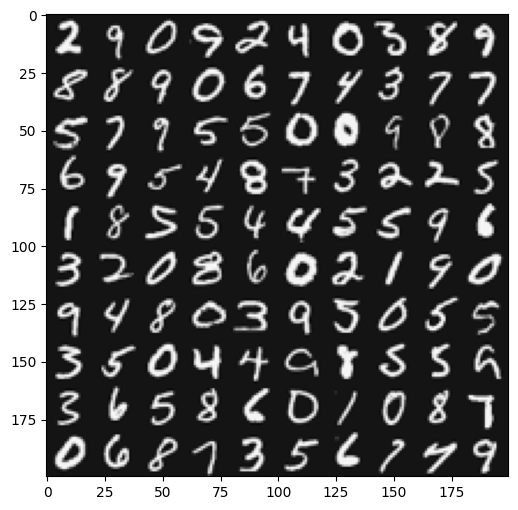

In [46]:
displayData()

## Vectorizing the Logistic Regression.



In [56]:
# Hypothesis function and cost function for the logistic regression.
def h(mytheta, myX):   # Logistic hypothesis function.
  return expit(np.dot(myX, mytheta))

def computeCost(mytheta,myX,myy,mylambda = 0.):
    m = myX.shape[0] #5000
    myh = h(mytheta,myX) #shape: (5000,1)
    term1 = np.log( myh ).dot( -myy.T ) #shape: (5000,5000)
    term2 = np.log( 1.0 - myh ).dot( 1 - myy.T ) #shape: (5000,5000)
    left_hand = (term1 - term2) / m #shape: (5000,5000)
    right_hand = mytheta.T.dot( mytheta ) * mylambda / (2*m) #shape: (1,1)
    return left_hand + right_hand #shape: (5000,5000)




### One vs all classification.

In [59]:
def costGradient(mytheta, myX, myy, mylambda=0.):
  m = myX.shape[0]
  # Transpose because it makes the unit to work out in dot products later.
  beta = h(mytheta, myX)-myy.T  # Shape (5000, 5000)

  # Regularization skips the first element in theta
  regterm = mytheta[1:] * (mylambda/m) # shape (400, 1)

  grad = (1./m) * np.dot(myX.T, beta) # shape (401, 5000)

  # regularization skips the first element in theta
  grad[1:] = grad[1:] + regterm
  return grad



In [54]:
from scipy import optimize


def optimizeTheta(mytheta, myX, myy, mylambda=0.):
  result = optimize.fmin_cg(computeCost, fprime=costGradient, x0=mytheta, \
                            args=(myX, myy, mylambda), maxiter=50, disp=False, \
                            full_output = True)

  return result[0], result[1]


In [57]:
def buildTheta():
  """ Function to detemine an optimized theta for each class and returns
  a Theta function where each row corresponds to the learned logistic regression
  params for one class
  """
  mylambda = 0
  initial_theta = np.zeros((X.shape[1], 1)).reshape(-1)
  Theta = np.zeros((10, X.shape[1]))
  for i in range(10):
    iclass = i if i  else 10 # class 10 correspond to handwritten 0
    print("Optimizing for hnadwritten number %d..."%i)
    logic_Y = np.array([1 if x ==  iclass else 0 for x in y])
    itheta, imincost =  optimizeTheta(initial_theta,X,  logic_Y, mylambda)
    Theta[i, :] = itheta
  print("Done")
  return Theta


In [60]:
Theta = buildTheta()

Optimizing for hnadwritten number 0...
Optimizing for hnadwritten number 1...
Optimizing for hnadwritten number 2...
Optimizing for hnadwritten number 3...
Optimizing for hnadwritten number 4...
Optimizing for hnadwritten number 5...
Optimizing for hnadwritten number 6...
Optimizing for hnadwritten number 7...
Optimizing for hnadwritten number 8...
Optimizing for hnadwritten number 9...
Done


In [67]:
def predictOneVsAll(myTheta, myrow):
  """
  Function that computes a hypothesis for an individual image (row in X)
  and returns the predicted integer corresponding to the handwritten image
  """

  classes = [10] + list(range(1, 10))
  hypots = [0]*len(classes)
  # Compute a hypothesis for each possible outcome
  # Choose the maximum hypothesis to find results
  for i in range(len(classes)):
    hypots[i] = h(myTheta[i], myrow)
  return classes[np.argmax(np.array(hypots))]

In [68]:
# "You should see that the training set accuracy is about 94.9%"

n_correct, n_total = 0., 0.
incorrect_indices = []
for irow in range(X.shape[0]):
    n_total += 1
    if predictOneVsAll(Theta,X[irow]) == y[irow]:
        n_correct += 1
    else: incorrect_indices.append(irow)
print("Training set accuracy: %0.1f%%"%(100*(n_correct/n_total)))


Training set accuracy: 95.4%


[142,
 265,
 765,
 1025,
 1026,
 1045,
 1057,
 1062,
 1066,
 1081,
 1087,
 1090,
 1097,
 1103,
 1112,
 1130,
 1145,
 1153,
 1187,
 1189,
 1207,
 1213,
 1231,
 1292,
 1311,
 1362,
 1363,
 1383,
 1399,
 1408,
 1410,
 1412,
 1413,
 1423,
 1440,
 1484,
 1488,
 1498,
 1524,
 1527,
 1550,
 1556,
 1564,
 1593,
 1599,
 1607,
 1611,
 1617,
 1618,
 1626,
 1628,
 1629,
 1630,
 1700,
 1701,
 1707,
 1719,
 1732,
 1764,
 1766,
 1769,
 1776,
 1791,
 1798,
 1801,
 1876,
 1879,
 1923,
 1945,
 1959,
 1970,
 1972,
 1976,
 1981,
 1999,
 2078,
 2087,
 2093,
 2104,
 2110,
 2112,
 2118,
 2166,
 2171,
 2187,
 2194,
 2195,
 2201,
 2238,
 2270,
 2277,
 2282,
 2384,
 2452,
 2498,
 2505,
 2506,
 2516,
 2520,
 2521]

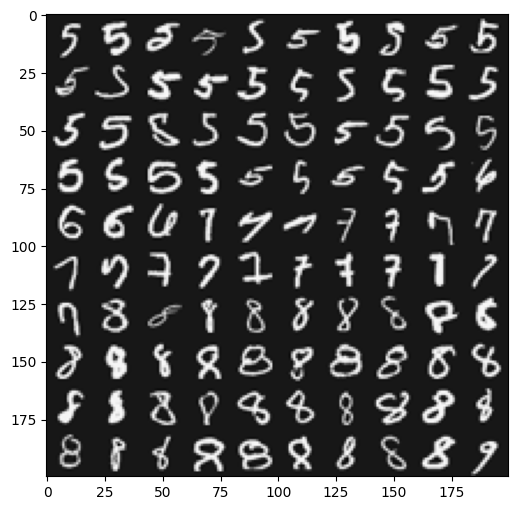

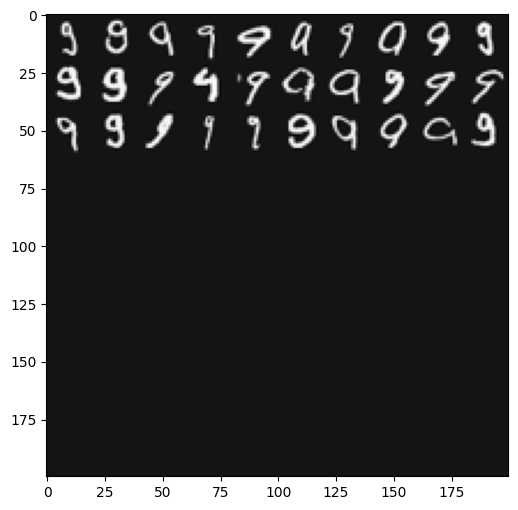

In [69]:
# Checking the ones that we got wrong
display(incorrect_indices[:100])
displayData(incorrect_indices[100:200])
displayData(incorrect_indices[200:300])


## Neural Networks
### Model representation.



In [70]:
# We have been provided with a set of network parameters (Θ(1),Θ(2))
datafile = 'data/ex3weights.mat'
mat = scipy.io.loadmat(datafile)
Theta1, Theta2 = mat["Theta1"], mat["Theta2"]
print("Theta1 has shape:", Theta1.shape)
print("Theta2 has shape:", Theta2.shape)


Theta1 has shape: (25, 401)
Theta2 has shape: (10, 26)


## Feedforward Propagation


In [74]:
def propagateForward(row, Thetas):
  """
  Function that given a list of Thetas, propagates the
  Row of features forwards, assuming the features already
  include the bias unit in the input layer, and the
  Thetas need the bias unit added to features between each layer
  """
  features = row
  for i in range(len(Thetas)):
    Theta = Thetas[i]
    z = Theta.dot(features)
    a = expit(z)
    if i == len(Thetas) -1:
      return a
    a = np.insert(a, 0, 1)
    features = a

def predictNN(row, Thetas):
  """
  Function that takes a row of features, propagates them through the
  NN, and returns the predicted integer that was hand written
  """
  classes = list(range(1, 10)) + [10]
  output = propagateForward(row, Thetas)
  return classes[np.argmax(np.array(output))]




In [77]:
# we could see that the accuracy is about 97.5%
myThetas = [Theta1, Theta2]

n_correct, n_total = 0, 0
incorrect_indices = []

for irow in range(X.shape[0]):
    n_total += 1
    if predictNN(X[irow], myThetas) == int(y[irow, 0]):
        n_correct += 1
    else:
        incorrect_indices.append(irow)

accuracy = 100 * n_correct / n_total
print(f"Training set accuracy: {accuracy:.1f}%")


Training set accuracy: 97.5%


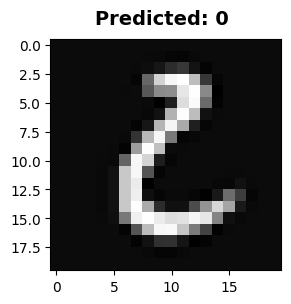

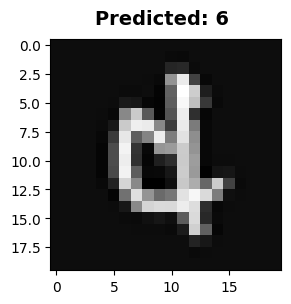

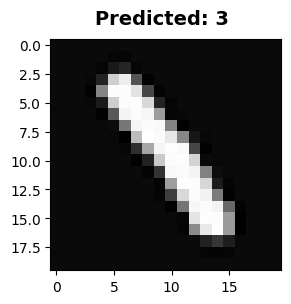

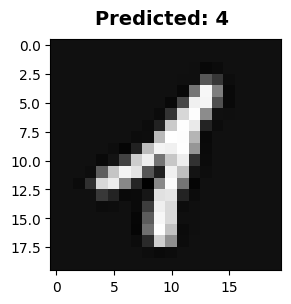

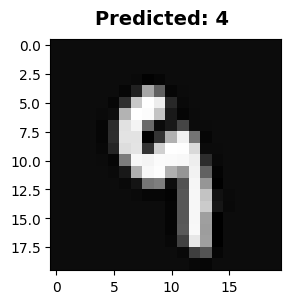

In [80]:
for x in range(5):
    i = random.choice(incorrect_indices)
    fig = plt.figure(figsize=(3, 3))

    img_array = getDatumImg(X[i])        # shape (20, 20)
    plt.imshow(img_array, cmap=cm.Greys_r)

    predicted_val = predictNN(X[i], myThetas)
    predicted_val = 0 if predicted_val == 10 else predicted_val

    fig.suptitle("Predicted: %d" % predicted_val, fontsize=14, fontweight='bold')
